In [7]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        filepath=os.path.join(dirname, filename)

In [8]:
df = pd.read_csv('/home/ayush/Documents/AI/Projects/MLOPS/Laptop_Price_Prediction_GCP_MLOPS/artifacts/DataIngestionArtifacts/gcp_bucket_laptop.csv')
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


# EDA

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), object(10)
me

In [10]:
df.isnull().sum().sum()  # Identifying null value = O nulls
df.duplicated().sum()   # Finding Duplicated = 0 Duplicates
df.shape
unique_entries = [df[col].unique() for col in df.columns]
df['Price (Inr)'] = df['Price (Euro)']*109.86

In [11]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory',
       'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)',
       'Price (Inr)'],
      dtype='object')

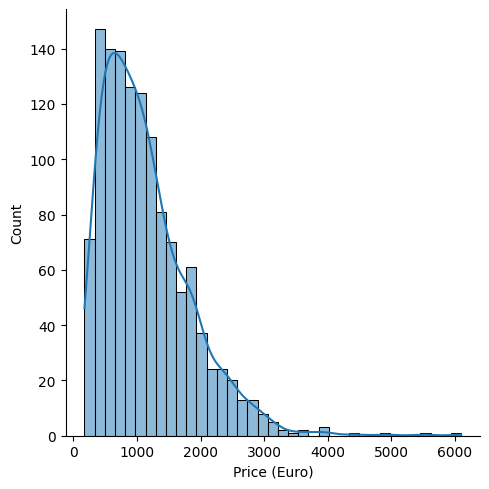

In [12]:
import seaborn as sns
sns.displot(df['Price (Euro)'],kde=True)

<Axes: xlabel='Company'>

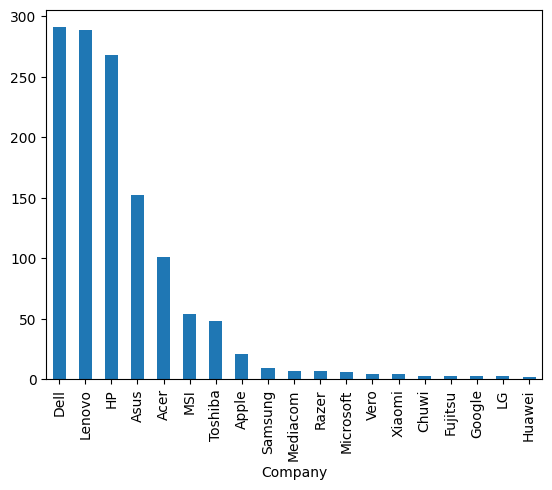

In [13]:
df['Company'].value_counts().plot(kind='bar')

<Axes: xlabel='OpSys'>

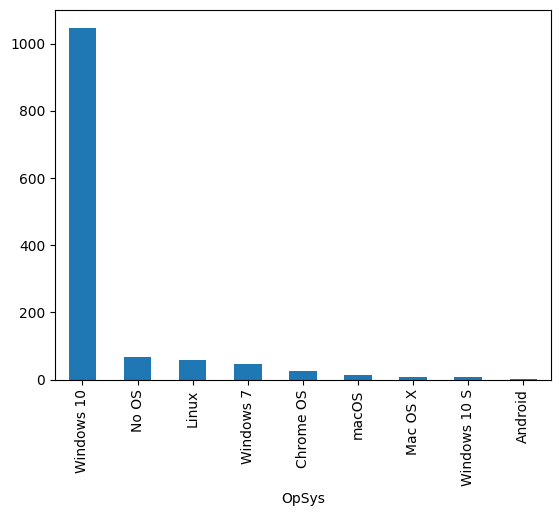

In [14]:
df['OpSys'].value_counts().plot(kind='bar')

<Axes: xlabel='GPU_Company'>

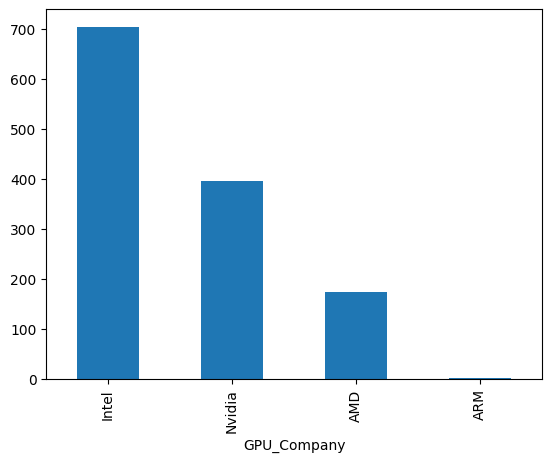

In [15]:
df['GPU_Company'].value_counts().plot(kind='bar')

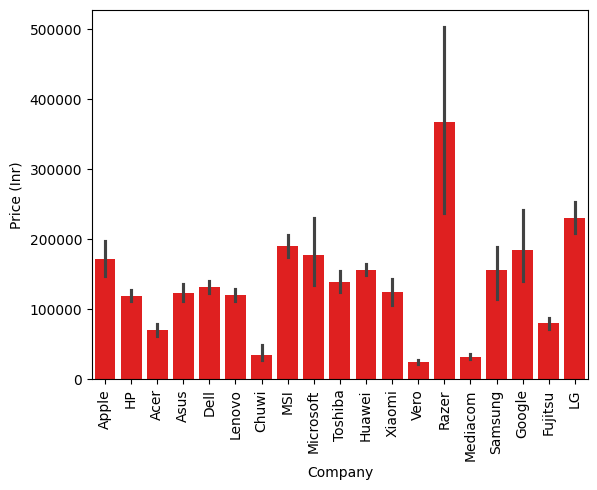

In [16]:
import matplotlib.pyplot as plt
sns.barplot(df,x="Company",y="Price (Inr)",color='red')
plt.xticks(rotation="vertical")
plt.show()

In [17]:
# mean_prices = df.groupby('4k')['Price (Inr)'].mean()
# pct_increase = ((mean_prices[1] - mean_prices[0]) / mean_prices[0]) * 100

# sns.barplot(data=df, x='4k', y='Price (Inr)', color='yellow')
# plt.xticks([0, 1], ['Non-4K', '4K'])
# plt.text(
#     0.5, 
#     max(mean_prices) * 0.95, 
#     f"+{pct_increase:.1f}%", 
#     ha='center', 
#     fontsize=14, 
#     color='green',
#     fontweight='bold'
# )

# plt.title("Price Comparison: Non-4K vs 4K")
# plt.show()

In [18]:
 # df.corr()['Price (Inr)']
df.select_dtypes(["int64","float64"]).corr()['Price (Inr)']

Inches                 0.066608
CPU_Frequency (GHz)    0.428847
RAM (GB)               0.740287
Weight (kg)            0.211883
Price (Euro)           1.000000
Price (Inr)            1.000000
Name: Price (Inr), dtype: float64

In [19]:
def cpu_tier(cpu):
    if 'Xeon' in cpu or 'i7' in cpu and ('HQ' in cpu or 'HK' in cpu):
        return 'high'
    elif 'i7' in cpu or 'Ryzen' in cpu or 'FX' in cpu:
        return 'mid_high'
    elif 'i5' in cpu:
        return 'mid'
    else:
        return 'low'
def gpu_tier(gpu):
    if any(x in gpu for x in ['GTX 1080','GTX 1070','GTX 1060','980','970','Quadro','FirePro']):
        return 'high'
    elif any(x in gpu for x in ['GTX 1050','GTX 960','RX 580','RX 560']):
        return 'mid_high'
    elif any(x in gpu for x in ['MX150','MX130','940','930','920','Radeon 530','Radeon 540']):
        return 'mid'
    else:
        return 'low'

def os_identifier(os):
    if os in ["macOS","Mac OS X"]:
        return 'macOS'
    elif os in ['Windows 10','Windows 10 S','Windows 7']:
        return 'Windows'
    else:
        return "Unpopular os"
def extract_series(name):
    keywords = ['MacBook','XPS','ThinkPad','ROG','Legion','Inspiron','Pavilion','EliteBook','ProBook','Aspire','ZenBook','VivoBook','Omen','Alienware']
    for k in keywords:
        if k.lower() in name.lower():
            return k
    return 'Other'

In [20]:
df['GPU_Tier'] = df['GPU_Type'].apply(lambda x:gpu_tier(x))
df['CPU_Tier'] = df['CPU_Type'].apply(lambda x:cpu_tier(x))
df['OpSys'] = df['OpSys'].apply(lambda x:os_identifier(x))
df['Product'] = df['Product'].apply(lambda x:extract_series(x))

In [21]:
premium = ['MacBook','XPS','ThinkPad','EliteBook','Spectre','Alienware','ROG']
df['is_premium'] = df['Product'].apply(lambda x: 1 if x in premium else 0)

In [22]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Price (Inr),GPU_Tier,CPU_Tier,is_premium
0,Apple,MacBook,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,147178.3434,low,mid,1
1,Apple,MacBook,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,98757.5484,low,mid,1
2,HP,Other,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,Unpopular os,1.86,575.00,63169.5000,low,mid,0
3,Apple,MacBook,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,278764.2570,low,mid_high,1
4,Apple,MacBook,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,198143.4960,low,mid,1


In [23]:
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [24]:
import re

def process_memory(mem):
    ssd = 0
    hdd = 0
    flash = 0
    
    parts = mem.split('+')
    
    for part in parts:
        part = part.strip()
        
        size = int(re.findall(r'\d+', part)[0])
        
        if 'TB' in part:
            size *= 1024
        if 'SSD' in part:
            ssd += size
        elif 'HDD' in part:
            hdd += size
        elif 'Flash' in part:
            flash += size
    
    return ssd, hdd, flash
df[['SSD','HDD','Flash']] = df['Memory'].apply(lambda x: pd.Series(process_memory(x)))

In [25]:
df.drop(columns=['Inches','Weight (kg)','Price (Euro)','CPU_Type','GPU_Type','ScreenResolution','Memory','Product'],inplace=True)

In [26]:
df.select_dtypes(["int64","float64"]).corr()['Price (Inr)']

CPU_Frequency (GHz)    0.428847
RAM (GB)               0.740287
Price (Inr)            1.000000
is_premium             0.479800
SSD                    0.670086
HDD                   -0.096599
Flash                 -0.037031
Name: Price (Inr), dtype: float64

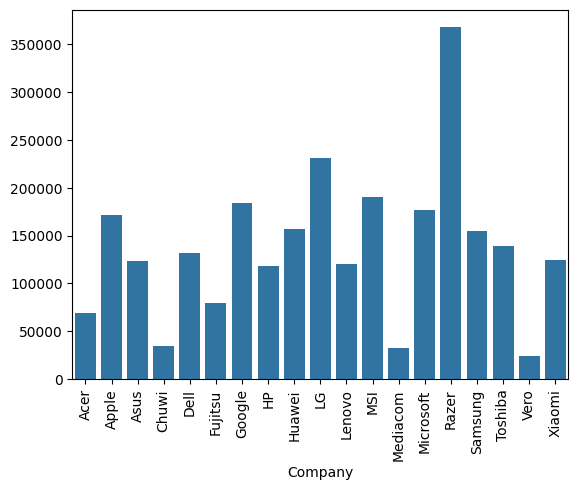

Company
Dell         291
Lenovo       289
HP           268
Asus         152
Acer         101
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64


In [27]:
df['Company'].value_counts()
company_mean_price = df.groupby('Company')['Price (Inr)'].mean()
sns.barplot(x=company_mean_price.index,y=company_mean_price.values)
plt.xticks(rotation="vertical")
plt.show()
print(df['Company'].value_counts())

In [28]:
def other_companies(companies):
    if companies in ['Vero','Xiaomi','Chuwi','Fujitsu','LG','Huawei']:
        return "other_companies"
    else:
        return companies
df['Company'] = df['Company'].apply(lambda x:pd.Series(other_companies(x)))

In [29]:
[f"{x} => {df[x].unique()}" for x in df.select_dtypes("object").columns]

["Company => ['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'other_companies' 'MSI'\n 'Microsoft' 'Toshiba' 'Razer' 'Mediacom' 'Samsung' 'Google']",
 "TypeName => ['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible'\n 'Workstation']",
 "CPU_Company => ['Intel' 'AMD' 'Samsung']",
 "GPU_Company => ['Intel' 'AMD' 'Nvidia' 'ARM']",
 "OpSys => ['macOS' 'Unpopular os' 'Windows']",
 "GPU_Tier => ['low' 'mid' 'mid_high' 'high']",
 "CPU_Tier => ['mid' 'mid_high' 'low' 'high']"]

# Training Phase

In [30]:
from sklearn.model_selection import train_test_split
X = df.drop(columns =['Price (Inr)'])
y = df['Price (Inr)']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15,random_state=2)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor,VotingRegressor,StackingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [32]:
print(X_train.shape)
X_train.head()

(1083, 13)


,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,GPU_Tier,CPU_Tier,is_premium,SSD,HDD,Flash
944,Lenovo,2 in 1 Convertible,Intel,1.2,8,Intel,Windows,low,low,0,256,0,0
21,Lenovo,Gaming,Intel,2.5,8,Nvidia,Windows,mid_high,mid,0,128,1024,0
530,Dell,Gaming,Intel,2.8,16,Nvidia,Windows,high,high,1,128,1024,0
279,Lenovo,Notebook,Intel,1.8,8,Nvidia,Unpopular os,mid,mid_high,0,0,2048,0
398,Dell,Workstation,Intel,2.8,8,Nvidia,Windows,high,high,0,256,0,0


In [33]:
# LinearRegression
step1 = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  LinearRegression()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
lrr2 = r2_score(y_test,y_pred)
lrmae = mean_absolute_error(y_test,y_pred)

R2 score 0.7924379195651101
MAE 25200.4604938986


In [34]:
# Ridge
step1 = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  Ridge()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
rir2 = r2_score(y_test,y_pred)
rimae = mean_absolute_error(y_test,y_pred)

R2 score 0.7919117327758795
MAE 25209.97604015877


In [35]:
# Lasso
step1 = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  Lasso()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
lar2 = r2_score(y_test,y_pred)
lamae = mean_absolute_error(y_test,y_pred)

R2 score 0.792424417560827
MAE 25198.978002974403


In [36]:
# KNeighborsRegressor
step1 = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  KNeighborsRegressor()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
knr2 = r2_score(y_test,y_pred)
knmae = mean_absolute_error(y_test,y_pred)

R2 score 0.742800131763727
MAE 24913.554141250002


In [37]:
# DecisionTreeRegressor
step1 = ColumnTransformer(
    transformers=[
        # ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  DecisionTreeRegressor()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
dtr2 = r2_score(y_test,y_pred)
dtmae = mean_absolute_error(y_test,y_pred)

R2 score 0.7031474272830596
MAE 27468.6351071875


In [38]:
# RandomForestRegressor
step1 = ColumnTransformer(
    transformers=[
        # ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  RandomForestRegressor()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
rfr2 = r2_score(y_test,y_pred)
rfmae = mean_absolute_error(y_test,y_pred)

R2 score 0.8131091382678236
MAE 22396.694538460415


In [39]:
# GradientBoostingRegressor
step1 = ColumnTransformer(
    transformers=[
        # ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  GradientBoostingRegressor()
pipegb = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
gbr2 = r2_score(y_test,y_pred)
gbmae = mean_absolute_error(y_test,y_pred)

R2 score 0.8085500205832257
MAE 22492.847927511368


In [40]:
# AdaBoostRegressor
step1 = ColumnTransformer(   
    transformers=[
        # ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  AdaBoostRegressor()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
agr2 = r2_score(y_test,y_pred)
agmae = mean_absolute_error(y_test,y_pred)

R2 score 0.748150252902172
MAE 30286.48449706436


In [41]:
# ExtraTreesRegressor
step1 = ColumnTransformer(
    transformers=[
        # ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  ExtraTreesRegressor()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
etr2 = r2_score(y_test,y_pred)
etmae = mean_absolute_error(y_test,y_pred)

R2 score 0.7861378342596096
MAE 23323.263663842183


In [42]:
# VotingRegressor
step1 = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
rf = RandomForestRegressor(n_estimators=350,random_state=3,max_samples=0.5,max_features=0.75,max_depth=15)
gbdt = GradientBoostingRegressor(n_estimators=100,max_features=0.5)
xgb = XGBRegressor(n_estimators=25,learning_rate=0.3,max_depth=5)
et = ExtraTreesRegressor(n_estimators=100,random_state=3,max_samples=0.5,max_features=0.75,max_depth=10, bootstrap=True)

step2 = VotingRegressor([('rf', rf), ('gbdt', gbdt), ('xgb',xgb), ('et',et)],weights=[5,1,1,1])

pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
vrr2 = r2_score(y_test,y_pred)
vrmae = mean_absolute_error(y_test,y_pred)

R2 score 0.8288272577000987
MAE 20921.382609790715


In [43]:
# svr
step1 = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  SVR()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
svr2 = r2_score(y_test,y_pred)
svmae = mean_absolute_error(y_test,y_pred)

R2 score -0.08307029440989244
MAE 61436.6006711326


In [44]:
# XGBRegressor
step1 = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
step2 =  XGBRegressor()
pipelr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipelr.fit(X_train,y_train)
y_pred = pipelr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
xgr2 = r2_score(y_test,y_pred)
xgmae = mean_absolute_error(y_test,y_pred)

R2 score 0.8221326191402369
MAE 21924.014973795576


In [45]:
# StackingRegressor
step1 = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),[3,4,9,10,11,12]),
        ('OneHotEncd',OneHotEncoder(drop='first'),[1,2,5,6]),
        ('OrdinalEncod',OrdinalEncoder(),[0,7,8]),
    ],remainder='passthrough'
)
estimators = [
    ('rf', RandomForestRegressor(n_estimators=350,random_state=3,max_samples=0.5,max_features=0.75,max_depth=15)),
    ('gbdt',GradientBoostingRegressor(n_estimators=100,max_features=0.5)),
    ('xgb', XGBRegressor(n_estimators=25,learning_rate=0.3,max_depth=5))
]

step2 = StackingRegressor(estimators=estimators, final_estimator=Ridge(alpha=100))
pipesr = Pipeline(
    [('step1',step1),
    ('step2',step2)]
)
pipesr.fit(X_train,y_train)
y_pred = pipesr.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
srr2 = r2_score(y_test,y_pred)
srmae = mean_absolute_error(y_test,y_pred)

R2 score 0.8352027290807975
MAE 20631.20543190146


In [46]:
# evaluation
print(f"linear regression : r2score {lrr2} , mae {lrmae}")
print(f"Ridge regression : r2score {rir2} , mae {rimae}")
print(f"lasso regression : r2score {lar2} , mae {lamae}")
print(f"Knn regression : r2score {knr2} , mae {knmae}")
print(f"Decision regression : r2score {dtr2} , mae {dtmae}")
print(f"Random forest regression : r2score {rfr2} , mae {rfmae}")
print(f"Gradient boosting regression : r2score {gbr2} , mae {gbmae}")
print(f"extra tree regression : r2score {etr2} , mae {etmae}")
print(f"ada boost regression : r2score {agr2} , mae {agmae}")
print(f"svr regression : r2score {svr2} , mae {svmae}")
print(f"xg regression : r2score {xgr2} , mae {xgmae}")
print(f"votign regression : r2score {vrr2} , mae {vrmae}")
print(f"StackingRegressor regression : r2score {srr2} , mae {srmae}")

linear regression : r2score 0.7924379195651101 , mae 25200.4604938986
Ridge regression : r2score 0.7919117327758795 , mae 25209.97604015877
lasso regression : r2score 0.792424417560827 , mae 25198.978002974403
Knn regression : r2score 0.742800131763727 , mae 24913.554141250002
Decision regression : r2score 0.7031474272830596 , mae 27468.6351071875
Random forest regression : r2score 0.8131091382678236 , mae 22396.694538460415
Gradient boosting regression : r2score 0.8085500205832257 , mae 22492.847927511368
extra tree regression : r2score 0.7861378342596096 , mae 23323.263663842183
ada boost regression : r2score 0.748150252902172 , mae 30286.48449706436
svr regression : r2score -0.08307029440989244 , mae 61436.6006711326
xg regression : r2score 0.8221326191402369 , mae 21924.014973795576
votign regression : r2score 0.8288272577000987 , mae 20921.382609790715
StackingRegressor regression : r2score 0.8352027290807975 , mae 20631.20543190146


In [47]:
import joblib as jb
jb.dump(df,'df.joblib')
jb.dump(pipesr,'StackingRegressor.joblib')

['StackingRegressor.joblib']

In [48]:
df= pd.read_csv('/home/ayush/Documents/AI/Projects/MLOPS/Laptop_Price_Prediction_GCP_MLOPS/artifacts/ModelTrainingArtifacts/train_df.csv')
X_train = df.drop(columns =['Price (Inr)'])
y_train = df['Price (Inr)']

X_train.head()

,Unnamed: 0.1,Unnamed: 0,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,GPU_Tier,CPU_Tier,is_premium,SSD,HDD,Flash
0,944,944,Lenovo,2 in 1 Convertible,Intel,1.2,8,Intel,Windows,low,low,0,256,0,0
1,21,21,Lenovo,Gaming,Intel,2.5,8,Nvidia,Windows,mid_high,mid,0,128,1024,0
2,530,530,Dell,Gaming,Intel,2.8,16,Nvidia,Windows,high,high,1,128,1024,0
3,279,279,Lenovo,Notebook,Intel,1.8,8,Nvidia,Unpopular os,mid,mid_high,0,0,2048,0
4,398,398,Dell,Workstation,Intel,2.8,8,Nvidia,Windows,high,high,0,256,0,0
